In [1]:
import numpy as np
from scipy import linalg

In [2]:
a = np.array([1,2,3]) # 默认行向量
print(a.transpose()) # 对一维数组无效
print(a.shape)

a_t = a[:, np.newaxis]
print(a_t)
print(a_t.shape)


[1 2 3]
(3,)
[[1]
 [2]
 [3]]
(3, 1)


In [3]:
# 初始化二维数组
a = np.array([[1,2,3,4]])
print(a.T)

[[1]
 [2]
 [3]
 [4]]


In [4]:
# 向量加法, 相同位置的元素相加, 维数不变
a = np.array([[1,2,3,4]]).T
b = np.array([[1,2,3,4]]).T
print(a + b)

[[2]
 [4]
 [6]
 [8]]


In [5]:
# 向量的数量乘法, 将标向量和每个元素相乘, 维数不变
a = np.array([[1,2,3,4]]).T
print(3 * a)

[[ 3]
 [ 6]
 [ 9]
 [12]]


# 向量之间的乘法
## 内积
参与内积运算的两个向量必须维数相等，运算规则是先将对应位置上的元素相乘，然后合并相加，向量内积的最终运算结果是一个标量。
$$
\mathbf{u} \cdot \mathbf{v} = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \\ \vdots \\ u_n \end{bmatrix} \cdot \begin{bmatrix} v_1 \\ v_2 \\ v_3 \\ \vdots \\ v_n \end{bmatrix} = u_1v_1 + u_2v_2 + u_3v_3 + \cdots + u_nv_n
$$

内积的另一种表达: $$\mathbf{u} \cdot \mathbf{v} = |\mathbf{u}||\mathbf{v}|\cos\theta$$
表示向量$\mu$在向量v上的投影长度乘v的模长, 如果v模长为1, 那么就是$\mu$的投影长度, 也就是按照v向量对u向量的**贡献值**. 

### 推导思路: 余弦定理
在单位圆坐标系中,a、b 两条边从原点出发,夹角为 θ。
设 b 边落在 x 轴上,则:
- 边 a 的端点坐标: $(a\cos\theta, a\sin\theta)$
- 边 b 的端点坐标: $(b, 0)$
- c 是连接这两个端点的第三边

由两点间距离公式:

$$
\begin{align*}
c^2 &= (b - a\cos\theta)^2 + (0 - a\sin\theta)^2 \\
&= (b - a\cos\theta)^2 + (a\sin\theta)^2 \\
&= b^2 - 2ab\cos\theta + a^2\cos^2\theta + a^2\sin^2\theta \\
&= a^2(\cos^2\theta + \sin^2\theta) + b^2 - 2ab\cos\theta \\
&= a^2 + b^2 - 2ab\cos\theta
\end{align*}
$$

即余弦定理: $c^2 = a^2 + b^2 - 2ab\cos\theta$

设 u、v 夹角为 θ,则 u − v 构成三角形第三边。

$$
\begin{align*}
\text{由余弦定理:} \quad |u-v|^2 &= |u|^2 + |v|^2 - 2|u||v|\cos\theta \\[6pt]
\text{由内积展开:} \quad |u-v|^2 &= (u-v)\cdot(u-v) \\
&= u\cdot u - 2\,u\cdot v + v\cdot v \\
&= |u|^2 + |v|^2 - 2\,u\cdot v \\[6pt]
\text{两式相等:} \quad |u|^2 + |v|^2 - 2\,u\cdot v &= |u|^2 + |v|^2 - 2|u||v|\cos\theta \\
u\cdot v &= |u||v|\cos\theta
\end{align*}
$$

### 应用
$$
\cos\theta = \frac{u\cdot v}{|u|\cdot|v|}
$$
判断两个向量的相似方向, 值越大代表越相似

In [6]:
a = np.array([1,2,3])
b = np.array([2,3,4])
print(np.dot(a, b))

20


## 外积
$$
\mathbf{u} \times \mathbf{v} = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix} \times \begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = u_1 v_2 - u_2 v_1
$$
二维平面的外积

In [7]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

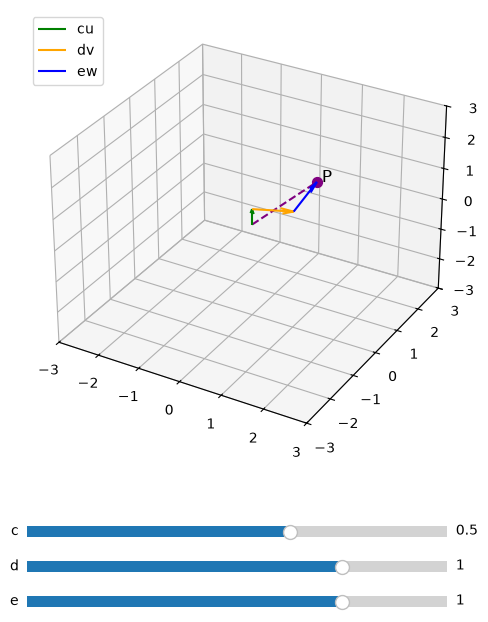

In [8]:
# 三个基向量 (可以是任意不共面的3D向量)
u = np.array([0, 0, 1])
v = np.array([1, 0, 0.3])
w = np.array([0, 1, 0.3])

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
plt.subplots_adjust(bottom=0.25)

def compute_points(c, d, e):
    O  = np.array([0, 0, 0])
    P1 = O + c*u
    P2 = P1 + d*v
    P3 = P2 + e*w
    return O, P1, P2, P3

def draw(c, d, e):
    ax.cla()
    O, P1, P2, P3 = compute_points(c, d, e)

    # 三段首尾相接的向量
    ax.quiver(*O,  *(P1-O), color='green',  label='cu')
    ax.quiver(*P1, *(P2-P1), color='orange', label='dv')
    ax.quiver(*P2, *(P3-P2), color='blue',   label='ew')

    # 合向量(虚线)与终点
    ax.plot([O[0], P3[0]], [O[1], P3[1]], [O[2], P3[2]],
            'purple', linestyle='--')
    ax.scatter(*P3, color='purple', s=50)
    ax.text(*P3, ' P', fontsize=12)

    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_zlim(-3, 3)
    ax.legend(loc='upper left')
    fig.canvas.draw_idle()

# 初始值
c0, d0, e0 = 0.5, 1, 1
draw(c0, d0, e0)

# 滑块
ax_c = plt.axes([0.2, 0.12, 0.6, 0.03])
ax_d = plt.axes([0.2, 0.07, 0.6, 0.03])
ax_e = plt.axes([0.2, 0.02, 0.6, 0.03])
s_c = Slider(ax_c, 'c', -2, 2, valinit=c0)
s_d = Slider(ax_d, 'd', -2, 2, valinit=d0)
s_e = Slider(ax_e, 'e', -2, 2, valinit=e0)

def on_change(val):
    draw(s_c.val, s_d.val, s_e.val)

s_c.on_changed(on_change)
s_d.on_changed(on_change)
s_e.on_changed(on_change)

plt.show()

## 基底
要想准确地描述向量,首先就要确定一组基底,然后通过求出向量**在各个基向量上的投影值**,最后才能确定在这个基上的坐标值。一般情况下,如果不做特殊说明,那么基向量都是选取沿着坐标轴正方向并且长度为 1 的向量,这样方便描述和计算。

### 构成基底的条件
1. 向量数量足够,一个 3 维向量无法用 2 个向量来表示(它们只能表示一个平面)
2. 向量线性无关。一组向量满足线性无关的条件,等价于满足线性组合表示方法的唯一性(反证法证明);如果线性相关,那么(以 3 个向量为例)第三个向量和前两个向量在同一个平面上

### 张成空间
对于一组向量,它的所有线性组合所构成的空间,就称为这一组向量的张成空间。

## 矩阵
### 方阵
行列数量相等的矩阵
### 转置
行列元素互换, $A^{T}$, 转置后相等的矩阵是**对称矩阵**——沿着从左上到右下的对角线,关于这条对角线相互对称的元素都是彼此相等的。

In [9]:
A = np.array([[1,2], [3,4]])
print(a.T)

[1 2 3]


### 零矩阵
所有元素为0的矩阵, $0_{5,3}$
### 对角矩阵
除了对角线以外全为0, $diag(x)y = x \odot y$

In [10]:
A = np.diag([1,2,3,4,5])
A

array([[1, 0, 0, 0, 0],
       [0, 2, 0, 0, 0],
       [0, 0, 3, 0, 0],
       [0, 0, 0, 4, 0],
       [0, 0, 0, 0, 5]])

### 单位矩阵
对角线元素全为1, 记为$I_{n}$

In [11]:
I = np.eye(5)
I

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

### 统一表示
n维行向量可以看作 $1 \times n$维的矩阵, n维列向量看作 $n \times 1$的矩阵. 在处理矩阵和向量乘法时可以作为矩阵乘法来处理.

In [12]:
A = np.array([[1,2,3,4]])
print(A)
print(A.shape)
print(A.T)
print(A.T.shape)

[[1 2 3 4]]
(1, 4)
[[1]
 [2]
 [3]
 [4]]
(4, 1)


### 矩阵加法
对应元素相加

### 矩阵 scalar 乘法
对应元素相乘

### 矩阵矩阵相乘
矩阵乘法的3条规则：

1. 相乘条件：左矩阵的列数必须等于右矩阵的行数
2. 结果行数：由左矩阵的行数决定
3. 结果列数：由右矩阵的列数决定

简记：$(m\times n) \times (n\times p) = (m\times p)$ —— 中间的 $n$ 必须相等，结果取两端的 $m$ 和 $p$。

In [13]:
A = np.array([[1,2], [1,2], [2,3]])
B = np.array([[2,1], [2,1]])
print(np.dot(A, B))

[[ 6  3]
 [ 6  3]
 [10  5]]


### 矩阵和列向量的运算
把列向量看作列数为1的特殊矩阵，运算过程就会很简单清晰：

$$
\begin{bmatrix}
a_{11} & a_{12} & a_{13} & \cdots & a_{1n} \\
a_{21} & a_{22} & a_{23} & \cdots & a_{2n} \\
a_{31} & a_{32} & a_{33} & \cdots & a_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & a_{m3} & \cdots & a_{mn}
\end{bmatrix}
\begin{bmatrix}
x_1 \\ x_2 \\ x_3 \\ \vdots \\ x_n
\end{bmatrix}
=
\begin{bmatrix}
a_{11}x_1 + a_{12}x_2 + a_{13}x_3 + \cdots + a_{1n}x_n \\
a_{21}x_1 + a_{22}x_2 + a_{23}x_3 + \cdots + a_{2n}x_n \\
a_{31}x_1 + a_{32}x_2 + a_{33}x_3 + \cdots + a_{3n}x_n \\
\vdots \\
a_{m1}x_1 + a_{m2}x_2 + a_{m3}x_3 + \cdots + a_{mn}x_n
\end{bmatrix}
$$

1. 矩阵在左，列向量在右，矩阵的列数必须等于列向量的维数
2. 矩阵和列向量相乘的结果也是一个列向量
3. 矩阵的行数就是结果向量的维数
4. 每行分别与列向量对应元素相乘后求和

### 列视角(重要)
$$
\begin{bmatrix} a & b \\ c & d \end{bmatrix}\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} a & b \\ c & d \end{bmatrix}\left(x\begin{bmatrix} 1 \\ 0 \end{bmatrix} + y\begin{bmatrix} 0 \\ 1 \end{bmatrix}\right) = x\begin{bmatrix} a & b \\ c & d \end{bmatrix}\begin{bmatrix} 1 \\ 0 \end{bmatrix} + y\begin{bmatrix} a & b \\ c & d \end{bmatrix}\begin{bmatrix} 0 \\ 1 \end{bmatrix} = x\begin{bmatrix} a \\ c \end{bmatrix} + y\begin{bmatrix} b \\ d \end{bmatrix}
$$
也就是基底的变化, 运算矩阵的各列就是**映射后的新基底**.

对于一个 m×n 的矩阵 A,n 维列向量经过 A 的乘法作用,n 个默认基向量被转换成了 n 个 m 维的目标向量。下面针对 n 和 m 的大小关系,分为以下几种情况进行讨论:

1. 当 n > m(矮胖) 时,显然这 n 个向量线性相关,因此不构成基底
2. 当 n < m(高瘦) 时,即使这 n 个向量线性无关,由于它们不能表示 m 维空间中的所有向量,因此也不能称为 m 维目标空间的基底
3. 当且仅当 n = m(方阵),且这 n 个向量线性无关时,它们才能作为目标空间中的一组基底

## 矩阵的本质是空间的映射
$ m \times n$的矩阵可以把n维空间($R^{n}$)中x的坐标向量映射到m维空间($R^{m}$)中的y坐标向量.本质是对列向量的线性组合. 空间维度的决定因素就是空间映射矩阵各列的线性相关性,由各列所张成的空间维数,就是原始空间映射后的像空间维数。 矩阵各列所张成空间的维数,被称为这个映射矩阵的**秩**。此外,秩也可以看作是该矩阵线性无关的列的个数,这两个说法相互之间是等价的。

In [14]:
A = np.array([[1, 2],
              [2, 4]])

rank = np.linalg.matrix_rank(A)
print(rank)  # 1

1


### 矮胖的映射
即m < n, 以 2 * 3的矩阵A为例, x是3 * 1的矩阵, Ax会把原始三维空间降维, 如果A的秩是2, 降维为2维, 如果秩为1, 降维为1维 
### 高瘦的映射
m > n, 以3 * 2的矩阵A为例, x是2*1的矩阵, Ax会把原始二维空间升维, 如果A秩为2, 会升维为三维空间中穿过原点的一个平面, 如果秩为1, 升维为三维空间中穿过原点的线

## 逆映射
$m \times n$ 的矩阵 A 可以把 n 维空间($R^{n}$)中 x 的坐标向量映射到
m 维空间($R^{m}$)中的 y 坐标向量,现在想找到把 y 空间坐标映射回 x
空间坐标的矩阵,记为 $A^{-1}$。
逆映射的完整定义,需要"满射"

一个映射 T: 定义域 → 陪域,要有逆映射(即陪域(就是目标空间)中每个元素都能找到唯一原像),必须同时满足:

* 单射(不同的 x 给出不同的 y)
* 满射(陪域中每一个元素都有原像)

### 矮胖的逆矩阵
A 矩阵 m < n,由前面可知 A 会进行降维,以 2×3 为例,列空间(像空间)
是 2 维的(是 $R^2$ 的子空间,若秩为 2 则占满 $R^2$)。找逆矩阵相当于
要把 2 维空间的向量映射回 3 维空间。以零向量为例,找 $x=[x_1,x_2,x_3]$
使 $Ax = [0,0]^T$,会发现 x 是 $R^3$ 中一条过原点的直线(零空间维数
≥ 1),也就是说 3 维空间中这条直线上的任何点都会被映射为 2 维空间中
的 $[0,0]^T$。所以逆映射不是**单射**(多个 x 对应同一个 y),没办法
找到唯一映射,也就没有逆矩阵。

### 高瘦的逆矩阵
A 矩阵 m > n,由前面可知 A 会进行升维,以 3×2 为例,列空间是 $R^3$
中的一个(至多)2 维子空间(平面或直线),不会占满整个 $R^3$。反过来
找逆映射时,**满射**条件满足不了,因为 $R^3$ 中不在这个像空间里的
向量,找不到对应的原像。

所以这两种情况都没有逆映射:矮胖矩阵因为**不是单射**(零空间非零),
高瘦矩阵因为**不是满射**(像空间没占满整个陪域)。

### 方阵的逆矩阵
为了同时满足单射和满射,方阵 A(n×n)要满足:
1. 零空间的维数为 0(即只有 $Ax=0$ 的唯一解 $x=0$)—— 保证单射
2. 列空间的维数为 n,即占满整个 $R^n$ —— 保证满射

这两个条件是等价的:等价于**列向量线性无关**(满秩,rank(A) = n)。

In [15]:

A = np.array([[1, 35, 0],
              [0, 2, 3],
              [0, 0, 4]])
A_n = linalg.inv(A)
print(np.dot(A, A_n))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## 向量空间
一直说的空间, 假设有个向量集合V, u, v选自V, 满足两点:
1. 加法封闭:u + v 还属于V
2. 数乘封闭: cu 还属于V
### 列空间
一个原始空间经过矩阵 A 的映射得到的对应空间,本质上就是该矩阵各列所有线性组合的结果集合,将其称为矩阵 A 的列空间 **C(A)**。

对于任意一个线性方程组,都可以将其写成矩阵乘法的形式:$Ax = b$。

只有当向量 b 可以写成 A 各列的线性组合形式时,才意味着这个方程组有解,即可以将 b 写作 $b = x_1a_1 + x_2a_2 + \cdots + x_na_n$(其中 $a_i$ 是 A 的第 i 列)。换句话说,对于线性方程组 $Ax = b$,**当且仅当向量 b 在矩阵 A 的列空间中时,方程组才有解**。

### 无穷多个解
如果 A 的列向量线性相关,那么至少存在一个非零向量 u 使得 $Au = 0$(零空间非平凡),这样的 u 有无穷多个(任意倍数 $cu$ 都满足 $A(cu)=0$)。进一步导致 $Ax = b$(若有解)会有无穷多个解:假设 v 是原方程的一个解($Av = b$),那么 $v + cu$ 对任意 c 也是解,因为 $A(v+cu) = Av + cAu = b + 0 = b$。

### 零空间
零空间(Null Space):所有满足 $Ax = 0$ 的向量 x 组成的集合,记作 **N(A)**。

$$N(A) = \{x \in \mathbb{R}^n : Ax = 0\}$$

x 本身就取自Rⁿ(原始空间),所以零空间里的每一个元素本来就是原始空间里的向量——它是 Rⁿ 的一个子集。


### 行空间
由A的行组成的线性组合的结果集合, A的行空间就是$A^{T} $的列空间, $C(A^{T})$. 

### 左零空间
$A^{T}$ 的零空间,即所有满足 $A^{T}y = 0$ 的向量 y 组成的集合,记作
$N(A^{T})$。之所以叫"左零空间",是因为它等价于所有满足 $y^{T}A = 0$
的行向量 y(A 左乘)。

### 秩连接四个空间
1. 零空间 N(A) 的维数是 n − r,r 是 A 的秩
2. 行空间 C(A^T) 的维数也等于矩阵的秩 r
3. 左零空间 N(A^T) 的维度是 m − r

## 向量空间的维度
所谓维度指两方面:
1. 这个空间中每个向量的元素个数
2. 至少需要多少个基向量才能张成这个空间
3. 上面两者在讨论整个空间时相等,但讨论子空间时不一定相等。比如一个
   五维空间,它的零空间可能是三维的——这个零空间内向量的元素个数
   仍然是 5(因为它存在于 $R^5$ 中),但只需要 3 个基向量的线性组合
   就能张成这个零空间。

矩阵 A:
$$A=\begin{pmatrix}1&2&3&4&5\\0&0&0&1&2\\0&0&0&0&0\end{pmatrix}$$

解 $Ax=0$,解向量的通解:
$$
x=\begin{pmatrix}x_1\\x_2\\x_3\\x_4\\x_5\end{pmatrix}
=\begin{pmatrix}-2x_2-3x_3+3x_5\\x_2\\x_3\\-2x_5\\x_5\end{pmatrix}
$$

拆分为三个基向量的线性组合(对应 3 个自由变量 $x_2, x_3, x_5$,零空间维数为 3):
$$
x=x_2\begin{pmatrix}-2\\1\\0\\0\\0\end{pmatrix}
+x_3\begin{pmatrix}-3\\0\\1\\0\\0\end{pmatrix}
+x_5\begin{pmatrix}3\\0\\0\\-2\\1\end{pmatrix}
$$

## 方程组
如果方程组有解,满足等式 $Ax = b$ 成立,那么向量 b 就是矩阵 A 各列的
某种线性组合。换句话说,只有向量 b 在矩阵 A 的列空间上,才能满足方
程组有解。Ax 本质上是对 A 的列向量做线性组合(系数是 x 的各分量)。
所以 Ax 取值的全部可能结果,就是 A 列向量能张成的空间——即列空间。
如果 b 不在这个列空间里,说明不存在任何组合系数 x,能让列向量组合出
b,方程自然无解。

例:

$$A=\begin{pmatrix}1&2\\2&4\end{pmatrix}, \quad b=\begin{pmatrix}1\\1\end{pmatrix}$$

A 的两列共线(都是 $(1,2)$ 的倍数),列空间只是一条直线 $\{(t,2t)\}$。

- $b=(1,1)$:不在这条直线上($1 \ne 2\times1$)→ 无解
- $b=(2,4)$:在这条直线上($t=2$)→ 有解,且 $x_1+2x_2=2$ 的组合都行

一句话:**有解 ⟺ b 能被 A 的列"拼"出来 ⟺ $b \in \text{Col}(A)$**

## 求解
## 通解 = 特解 + 零空间

当方程组 $Ax=b$ 有唯一解时,解本身就是一个向量 x,这是唯一表达方式。

当方程组有无穷多解时,需要描述整个解空间:

1. **找一个特解 $x_p$**:任意找一个满足 $Ax_p = b$ 的解
2. **利用零空间**:零空间中任意向量 $x_s$ 满足 $Ax_s = 0$,将其与特解相加:
   $$Ax_p + Ax_s = b + 0 \Rightarrow A(x_p + x_s) = b$$
   说明 **特解 + 零空间中任意向量,仍然是方程组的解**
3. **几何理解**:把整个零空间沿着特解向量 $x_p$ 平移,得到的就是完整的解空间
4. **描述零空间**:找零空间的一组基 $e_1, e_2, \ldots, e_{n-r}$(共 $n-r$ 个,n 是原始空间维数,r 是秩),零空间中任意向量可表示为:
   $$x_n = c_1e_1 + c_2e_2 + \cdots + c_{n-r}e_{n-r}$$
5. **通解公式**:
   $$x = x_p + x_n = x_p + c_1e_1 + c_2e_2 + \cdots + c_{n-r}e_{n-r}$$

**特殊情况**:当 A 是满秩方阵时,零空间只有零向量一个点(维数为 0),
所以通解退化为 $x = x_p$——这解释了为什么此时方程组只有唯一解。唯一
解可以看作"无穷多解"这个通用框架下的一个特殊情况(零空间维度 = 0)。

In [16]:
A = np.array([[1, 2, 3],
              [1, -1, 4],
              [2, 3, -1]])
y = np.array([14, 11, 5])
x = linalg.solve(A, y)
print(x)

[1. 2. 3.]


## 相似矩阵
对 于 空 间 位 置 里 的 同 一 个 向 量 ， 选 取 不 同 的 基 底 进 行 表 示 ， 其 坐 标 值 就 是 不 同 的 。对 于 空 间 中 的 同 一 个 位 置 变 换 ． 在 不 同 的 基 底 下 ， 用 于 描 述 的 阵 也 是 不 相 同 的 ， 而 这 些 不 同 违 阵
所 描 述 的 线 性 变 换 是 相 似 的 ， 它 们 也 被 称 为 相 似 阵 ， 这 些 阵 之 间 的 代 数 关 系 和 其 对 应 基 底 之 间
的 数 量 转 换 关 系 经 过 计 算 发 现 是 完 全 对 应 的 。

## Orthogonal vectors
两个向量垂直 (perpendicular)：
$$ u^T v = 0 $$
## Orthonormal vectors
orthogonal，且都是 unit vector：
$$ u^T v = 0,\quad \|u\| = \|v\| = 1 $$
## Orthogonal matrix
方阵，且 columns（以及 rows）两两 orthonormal，所以
$$ A^T A = A A^T = I $$
$$ A^T = A^{-1} $$

## Overdetermined vs Underdetermined
$$ Ax = b,\quad A \in \mathbb{R}^{m\times n} $$
($m$ 个方程，$n$ 个未知数)
- $m > n$：overdetermined，**通常**无解 → 最小二乘 $\min_x \|Ax-b\|^2$
- $m < n$：underdetermined，**通常**无穷多解 → 最小范数解 $\min \|x\|$ s.t. $Ax=b$（或正则化）
- 有没有解取决于rank

## Solutions of system of linear equations
$$ Ax = b,\quad A \in \mathbb{R}^{m\times n} $$
1. 无解：$\text{rank}(A) < \text{rank}([A\,|\,b])$
2. 有解：$\text{rank}(A) = \text{rank}([A\,|\,b])$
   - 唯一解：$\text{rank}(A) = n$
   - 无穷多解：$\text{rank}(A) < n$